In [6]:
import numpy as np

In [24]:
path = r'C:\Users\Ahad Imran\Downloads\vectorized-video-frames-labelled\vectorized-vidoe-frames-labelled.bin'
results = np.memmap(path, dtype='float32', mode='r', shape=(68700, 1, 128, 128, 14))

In [9]:
# To get the image vectors:
results[:,0,:,:,:3].shape

# To get x, y, w, h
results[:,0,0,0,3:7].shape

# To get class {-1: traffic-light, 1: pedestrian}
results[:,0,0,0,7]

# To get labels 'occlusion','state','action','gesture','cross','look'
results[:,0,0,0,8:14]

memmap([[2., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 3., 0., 0., 0., 0.],
        ...,
        [1., 0., 0., 0., 0., 0.],
        [2., 0., 0., 0., 0., 0.],
        [2., 0., 0., 0., 0., 0.]], shape=(68700, 6), dtype=float32)

In [25]:
import matplotlib.pyplot as plt

# Find first traffic light entry (class == -1)
classes = results[:, 0, 0, 0, 7]
tl_indices = np.where(classes == -1)[0]
print(f"Found {len(tl_indices)} traffic light entries. Showing index {tl_indices[0]}.")



Found 23 traffic light entries. Showing index 390.


In [18]:
# Inspect all label values for traffic light entries
tl_labels = results[tl_indices, 0, 0, 0, 8:14]
label_names = ['occlusion', 'state', 'action', 'gesture', 'cross', 'look']

print("All traffic light label values:\n")
for name, col in zip(label_names, tl_labels.T):
    unique_vals = np.unique(col)
    print(f"  {name:12s}: unique values = {unique_vals}")

print(f"\nFull label matrix for all {len(tl_indices)} traffic light entries:")
print(f"{'idx':>6}  " + "  ".join(f"{n:>10}" for n in label_names))
for i, (idx, row) in enumerate(zip(tl_indices, tl_labels)):
    print(f"{idx:>6}  " + "  ".join(f"{v:>10.0f}" for v in row))

All traffic light label values:

  occlusion   : unique values = [0.]
  state       : unique values = [0. 1. 3.]
  action      : unique values = [0.]
  gesture     : unique values = [0.]
  cross       : unique values = [0.]
  look        : unique values = [0.]

Full label matrix for all 23 traffic light entries:
   idx   occlusion       state      action     gesture       cross        look
   390           0           3           0           0           0           0
  3220           0           3           0           0           0           0
  3680           0           3           0           0           0           0
  3690           0           0           0           0           0           0
  3720           0           0           0           0           0           0
  3770           0           3           0           0           0           0
  3800           0           3           0           0           0           0
 19390           0           1           0           0

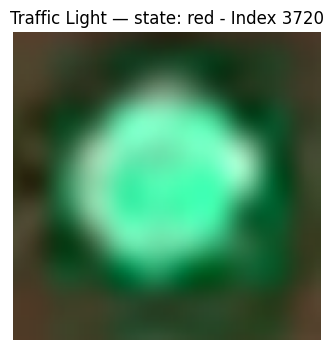

In [23]:
# Extract image (128x128x3) and normalize to [0, 1] for display
index = 4

img = results[tl_indices[index], 0, :, :, :3]
img_normalized = (img - img.min()) / (img.max() - img.min() + 1e-8)

state_label = results[tl_indices[0], 0, 0, 0, 8]
state_map = {0: 'red', 1: 'yellow', 2: 'green'}
state_str = state_map.get(int(state_label), f'unknown ({state_label})')

plt.figure(figsize=(4, 4))
plt.imshow(img_normalized)
plt.title(f'Traffic Light — state: {state_str} - Index {tl_indices[index]}')
plt.axis('off')
plt.show()